✅ Setup complete.
orders:      (646945, 8)
order_items: (714669, 7)
web_traffic: (3652, 7)
promotions:  (50, 10)
payments:    (646945, 4)
sales:       (3833, 3)
customers:   (121930, 7)
✅ Date columns casted successfully.

💰 SECTION 1: MARKETING BUDGET REALLOCATION

=== Channel Performance Matrix ===
shape: (6, 7)
┌──────────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┐
│ traffic_sour ┆ total_sessi ┆ bounce_rate ┆ conversion_ ┆ total_reven ┆ revenue_per ┆ avg_order_v │
│ ce           ┆ ons         ┆ _pct        ┆ rate_pct    ┆ ue          ┆ _session    ┆ alue        │
│ ---          ┆ ---         ┆ ---         ┆ ---         ┆ ---         ┆ ---         ┆ ---         │
│ str          ┆ i64         ┆ f64         ┆ f64         ┆ f64         ┆ f64         ┆ f64         │
╞══════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╡
│ social_media ┆ 15816226    ┆ 0.447476    ┆ 0.820107    ┆ 3.1412e9    ┆ 198.6

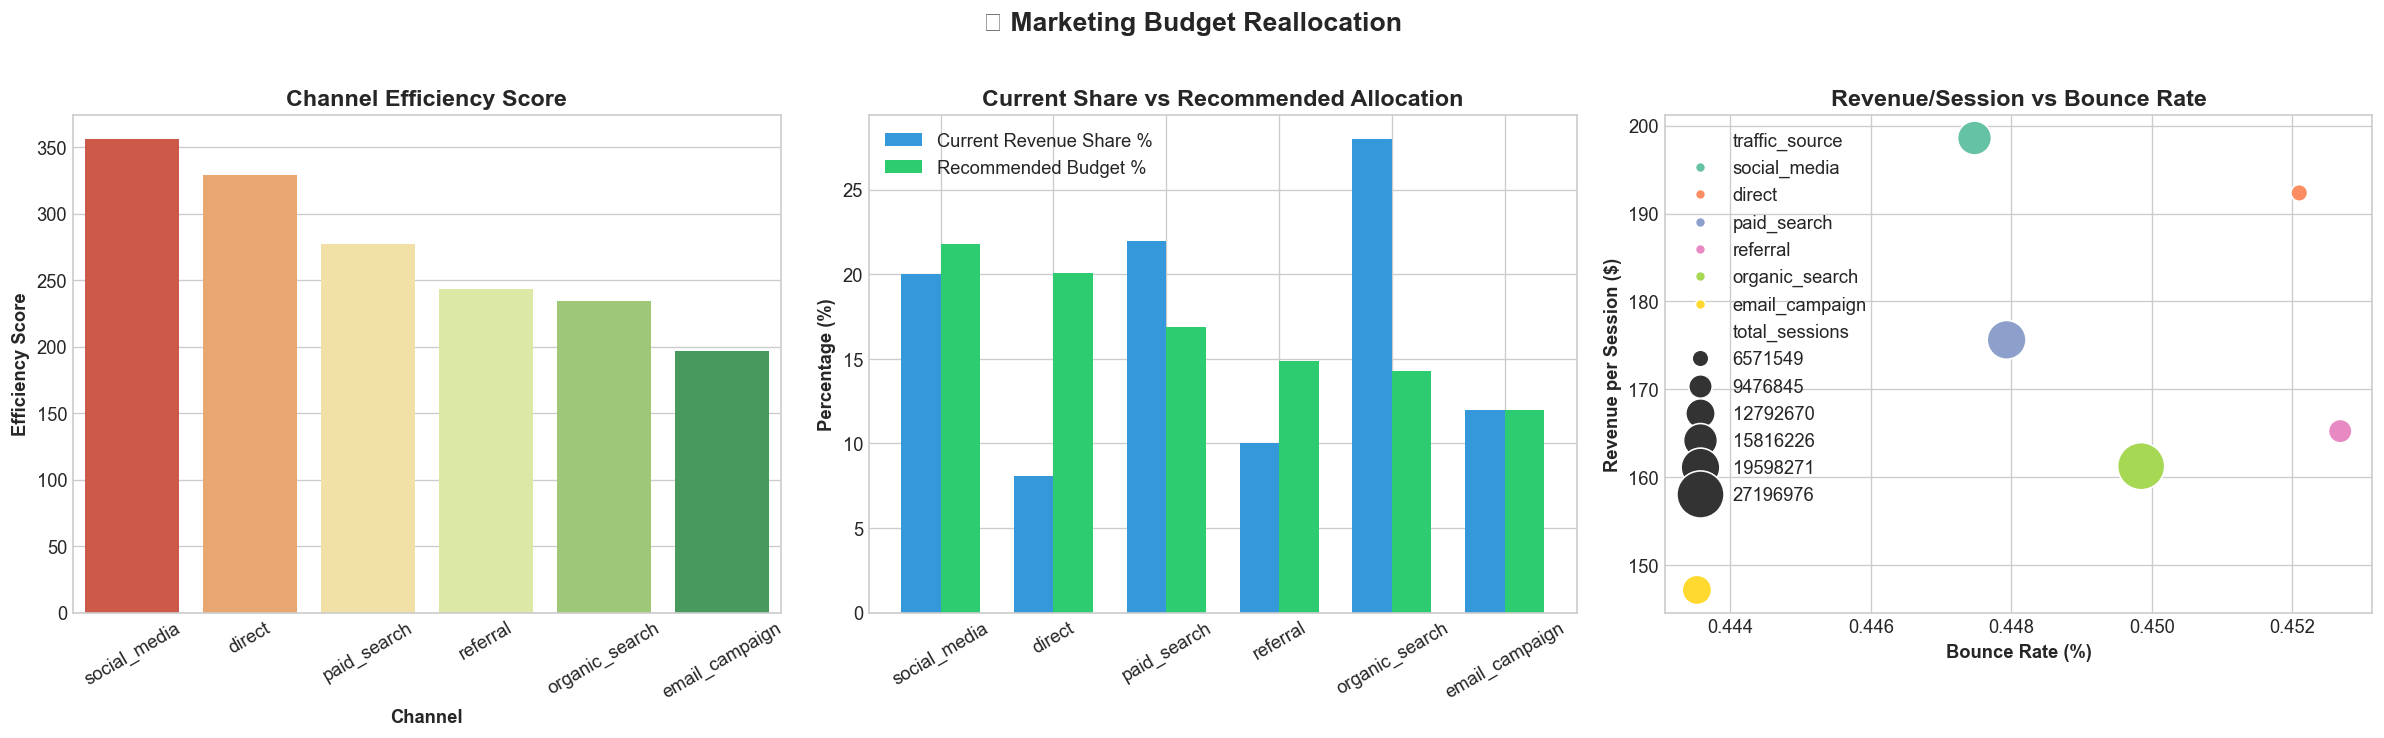


🎯 SECTION 2: PROMO STRATEGY BY SEGMENT

=== Customer Spend Segments ===
shape: (4, 4)
┌───────────────┬─────────────┬───────────────┬────────────┐
│ spend_segment ┆ n_customers ┆ avg_spend     ┆ avg_orders │
│ ---           ┆ ---         ┆ ---           ┆ ---        │
│ str           ┆ u32         ┆ f64           ┆ f64        │
╞═══════════════╪═════════════╪═══════════════╪════════════╡
│ VIP           ┆ 22562       ┆ 473394.949037 ┆ 18.459445  │
│ High          ┆ 22561       ┆ 150013.827994 ┆ 6.19055    │
│ Medium        ┆ 22562       ┆ 57038.928629  ┆ 2.650873   │
│ Low           ┆ 22561       ┆ 14571.966852  ┆ 1.373565   │
└───────────────┴─────────────┴───────────────┴────────────┘

=== Promo Effectiveness by Segment ===
shape: (4, 6)
┌───────────────┬─────────────┬─────────────────┬────────────────┬────────────────┬────────────────┐
│ spend_segment ┆ promo_items ┆ discount_depth_ ┆ avg_net_rev_pe ┆ avg_rev_per_no ┆ promo_uplift_p │
│ ---           ┆ ---         ┆ pct            

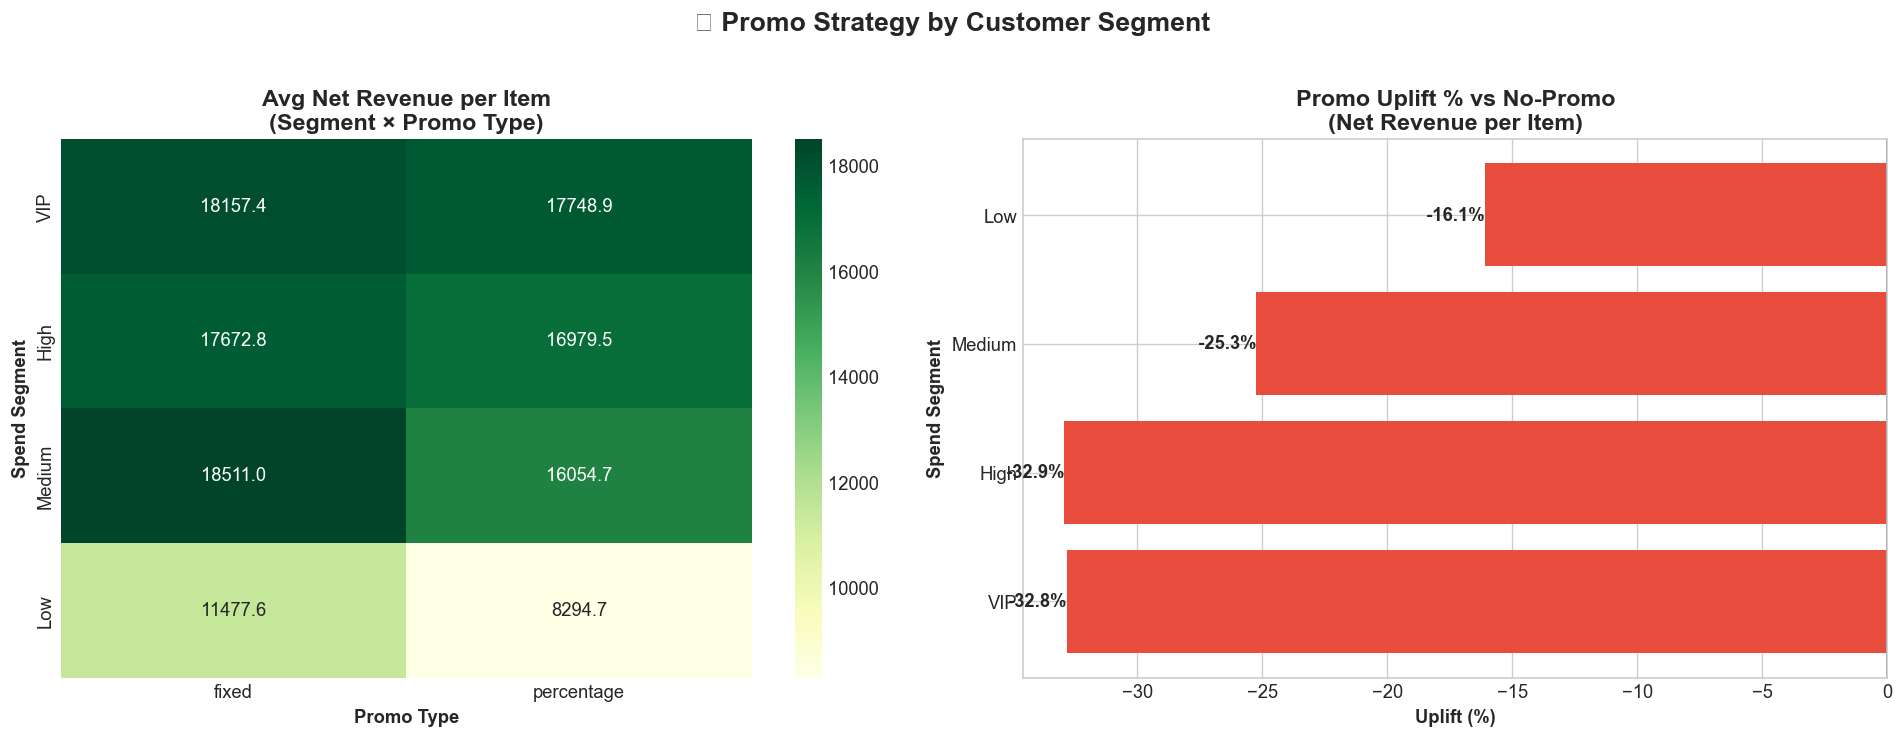


=== 🎯 Prescriptive Promo Recommendations by Segment ===

  [High Segment]
    → Discount Depth: 13.7% | Uplift: -32.9%
    → Chiến lược: Cross-sell (promo bundle), Tiered Discounts
    → Mục tiêu: Nâng lên VIP qua frequency programs

  [Low Segment]
    → Discount Depth: 14.2% | Uplift: -16.1%
    → Chiến lược: Win-back campaigns, First-purchase incentives
    → Cẩn thận: Không nên đầu tư quá nhiều vào segment này nếu uplift âm

  [Medium Segment]
    → Discount Depth: 13.8% | Uplift: -25.3%
    → Chiến lược: Flash Sales, Seasonal Promos
    → Mục tiêu: Tăng order frequency

  [VIP Segment]
    → Discount Depth: 13.8% | Uplift: -32.8%
    → Chiến lược: Loyalty Reward, Early Access, Bundle Deals
    → Tránh discount sâu — VIP đã có commitment cao

📝 PRESCRIPTIVE SUMMARY — Module ❺ (Marketing)

🎯 ACTION ITEMS:

1. MARKETING BUDGET REALLOCATION
   - Tăng budget cho channels có Efficiency Score cao (conversion × revenue/session ÷ bounce)
   - Giảm budget cho channels có bounce rate cao + 

In [1]:
"""
Day 5: EDA Prescriptive — Module ❺ (Marketing Prescriptive)
Owner: Nguyễn Quốc Khánh (Tech Lead)
Output: 04_M5_marketing_prescriptive.ipynb

Mục tiêu:
  1. Tái phân bổ ngân sách marketing dựa trên ROI theo channel.
  2. Chiến lược khuyến mãi (KM) tối ưu theo customer segment.
"""

# ============================================================
# CELL 1: Setup & Imports
# ============================================================
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sys
import os
import warnings
from datetime import timedelta

# %matplotlib inline

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath(os.path.join("..", "src")))
sys.path.append(os.path.abspath("src"))

try:
    from data_loader import DataLoader
except ImportError:
    print("Warning: data_loader module not found, make sure src/data_loader.py exists.")

np.random.seed(42)
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.titlesize": 14})

FIGURES_DIR = os.path.abspath(os.path.join("..", "figures"))
os.makedirs(FIGURES_DIR, exist_ok=True)
print("✅ Setup complete.")


# ============================================================
# CELL 2: Load Data
# ============================================================
loader = DataLoader()

orders = loader.load("orders")
order_items = loader.load("order_items")
web_traffic = loader.load("web_traffic")
promotions = loader.load("promotions")
payments = loader.load("payments")
sales = loader.load("sales")
customers = loader.load("customers")
products = loader.load("products")

print(f"orders:      {orders.shape}")
print(f"order_items: {order_items.shape}")
print(f"web_traffic: {web_traffic.shape}")
print(f"promotions:  {promotions.shape}")
print(f"payments:    {payments.shape}")
print(f"sales:       {sales.shape}")
print(f"customers:   {customers.shape}")


# ============================================================
# CELL 3: Date Casting
# ============================================================
if web_traffic["date"].dtype == pl.String:
    web_traffic = web_traffic.with_columns(
        pl.col("date").str.strptime(pl.Date, "%Y-%m-%d", strict=False).cast(pl.Datetime).alias("session_date")
    )
else:
    web_traffic = web_traffic.with_columns(pl.col("date").cast(pl.Datetime).alias("session_date"))

if orders["order_date"].dtype == pl.String:
    orders = orders.with_columns(
        pl.col("order_date").str.strptime(pl.Date, "%Y-%m-%d", strict=False).cast(pl.Datetime)
    )
else:
    orders = orders.with_columns(pl.col("order_date").cast(pl.Datetime))

if sales["Date"].dtype == pl.String:
    sales = sales.with_columns(pl.col("Date").str.strptime(pl.Date, "%Y-%m-%d", strict=False).cast(pl.Datetime))
else:
    sales = sales.with_columns(pl.col("Date").cast(pl.Datetime))

for col in ["start_date", "end_date"]:
    if promotions[col].dtype == pl.String:
        promotions = promotions.with_columns(
            pl.col(col).str.strptime(pl.Date, "%Y-%m-%d", strict=False).cast(pl.Datetime)
        )
    else:
        promotions = promotions.with_columns(pl.col(col).cast(pl.Datetime))

print("✅ Date columns casted successfully.")


# ============================================================
# SECTION 1: MARKETING BUDGET REALLOCATION
# ============================================================

# ============================================================
# CELL 4: 1.1 — Channel Performance Matrix
# ============================================================
print("\n" + "=" * 60)
print("💰 SECTION 1: MARKETING BUDGET REALLOCATION")
print("=" * 60)

# Bounce rate và sessions theo traffic source
web_traffic = web_traffic.with_columns(
    (pl.col("sessions") * pl.col("bounce_rate")).alias("bounces")
)

traffic_stats = web_traffic.group_by("traffic_source").agg(
    pl.col("sessions").sum().alias("total_sessions"),
    pl.col("unique_visitors").sum().alias("total_unique_visitors"),
    pl.col("bounces").sum().alias("total_bounces"),
    pl.col("page_views").sum().alias("total_page_views"),
    pl.col("avg_session_duration_sec").mean().alias("avg_session_duration"),
).with_columns(
    (pl.col("total_bounces") / pl.col("total_sessions") * 100).alias("bounce_rate_pct"),
    (pl.col("total_page_views") / pl.col("total_sessions")).alias("pages_per_session"),
)

# Revenue per channel từ orders + payments
order_revenue = payments.group_by("order_id").agg(
    pl.col("payment_value").sum().alias("order_revenue")
)
orders_with_rev = orders.join(order_revenue, on="order_id", how="left")

channel_revenue = orders_with_rev.group_by("order_source").agg(
    pl.count().alias("total_orders"),
    pl.col("order_revenue").sum().alias("total_revenue"),
).rename({"order_source": "traffic_source"})

# Merge traffic + revenue
channel_matrix = traffic_stats.join(channel_revenue, on="traffic_source", how="left")
channel_matrix = channel_matrix.with_columns([
    (pl.col("total_orders").fill_null(0) / pl.col("total_sessions") * 100).alias("conversion_rate_pct"),
    (pl.col("total_revenue").fill_null(0) / pl.col("total_orders").fill_null(1)).alias("avg_order_value"),
    (pl.col("total_revenue").fill_null(0) / pl.col("total_sessions")).alias("revenue_per_session"),
]).sort("revenue_per_session", descending=True)

print("\n=== Channel Performance Matrix ===")
print(channel_matrix.select([
    "traffic_source", "total_sessions", "bounce_rate_pct",
    "conversion_rate_pct", "total_revenue", "revenue_per_session", "avg_order_value",
]))


# ============================================================
# CELL 5: 1.2 — Efficiency Score & Budget Recommendation
# ============================================================
# Tính Efficiency Score = Conversion Rate × Revenue per Session / Bounce Rate
# Càng cao = channel càng hiệu quả → nên tăng budget
channel_matrix = channel_matrix.with_columns(
    (
        pl.col("conversion_rate_pct")
        * pl.col("revenue_per_session")
        / (pl.col("bounce_rate_pct") + 0.01)  # avoid div by 0
    ).alias("efficiency_score")
)

# Normalize score → allocate % budget
total_score = channel_matrix["efficiency_score"].sum()
channel_matrix = channel_matrix.with_columns(
    (pl.col("efficiency_score") / total_score * 100).round(1).alias("recommended_budget_pct")
)

# Current share (by revenue) để so sánh
total_rev = channel_matrix["total_revenue"].sum()
channel_matrix = channel_matrix.with_columns(
    (pl.col("total_revenue").fill_null(0) / total_rev * 100).round(1).alias("current_revenue_share_pct")
)

print("\n=== Budget Reallocation Recommendation ===")
print(channel_matrix.select([
    "traffic_source", "efficiency_score",
    "current_revenue_share_pct", "recommended_budget_pct",
]))

# Visualization
ch_pd = channel_matrix.to_pandas()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Chart 1: Efficiency Score
sns.barplot(data=ch_pd.sort_values("efficiency_score", ascending=False),
            x="traffic_source", y="efficiency_score", palette="RdYlGn", ax=axes[0])
axes[0].set_title("Channel Efficiency Score", fontweight="bold")
axes[0].set_xlabel("Channel", fontweight="bold")
axes[0].set_ylabel("Efficiency Score", fontweight="bold")
axes[0].tick_params(axis="x", rotation=30)

# Chart 2: Current vs Recommended Budget
x = np.arange(len(ch_pd))
w = 0.35
axes[1].bar(x - w/2, ch_pd["current_revenue_share_pct"], w, label="Current Revenue Share %", color="#3498db")
axes[1].bar(x + w/2, ch_pd["recommended_budget_pct"], w, label="Recommended Budget %", color="#2ecc71")
axes[1].set_xticks(x)
axes[1].set_xticklabels(ch_pd["traffic_source"], rotation=30)
axes[1].set_title("Current Share vs Recommended Allocation", fontweight="bold")
axes[1].set_ylabel("Percentage (%)", fontweight="bold")
axes[1].legend()

# Chart 3: Revenue per Session vs Bounce Rate (Bubble)
sns.scatterplot(
    data=ch_pd, x="bounce_rate_pct", y="revenue_per_session",
    size="total_sessions", hue="traffic_source", sizes=(100, 800),
    palette="Set2", ax=axes[2],
)
axes[2].set_title("Revenue/Session vs Bounce Rate", fontweight="bold")
axes[2].set_xlabel("Bounce Rate (%)", fontweight="bold")
axes[2].set_ylabel("Revenue per Session ($)", fontweight="bold")

plt.suptitle("💰 Marketing Budget Reallocation", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "day5_budget_reallocation.png"))
plt.show()


# ============================================================
# SECTION 2: PROMOTION STRATEGY BY SEGMENT
# ============================================================

# ============================================================
# CELL 6: 2.1 — Customer Segmentation (RFM-lite)
# ============================================================
print("\n" + "=" * 60)
print("🎯 SECTION 2: PROMO STRATEGY BY SEGMENT")
print("=" * 60)

# Tính tổng chi tiêu từng customer
customer_spend = orders_with_rev.group_by("customer_id").agg(
    pl.count().alias("order_count"),
    pl.col("order_revenue").sum().alias("total_spend"),
    pl.col("order_date").max().alias("last_order_date"),
)

# Merge demographic info
customer_profile = customer_spend.join(
    customers.select(["customer_id", "city", "gender", "age_group", "acquisition_channel"]),
    on="customer_id",
    how="left",
)

# Segment theo spending tier
q25 = customer_profile["total_spend"].quantile(0.25)
q50 = customer_profile["total_spend"].quantile(0.50)
q75 = customer_profile["total_spend"].quantile(0.75)

customer_profile = customer_profile.with_columns(
    pl.when(pl.col("total_spend") >= q75).then(pl.lit("VIP"))
    .when(pl.col("total_spend") >= q50).then(pl.lit("High"))
    .when(pl.col("total_spend") >= q25).then(pl.lit("Medium"))
    .otherwise(pl.lit("Low"))
    .alias("spend_segment")
)

segment_summary = customer_profile.group_by("spend_segment").agg(
    pl.count().alias("n_customers"),
    pl.col("total_spend").mean().alias("avg_spend"),
    pl.col("order_count").mean().alias("avg_orders"),
).sort("avg_spend", descending=True)

print("\n=== Customer Spend Segments ===")
print(segment_summary)


# ============================================================
# CELL 7: 2.2 — Promo Effectiveness by Customer Segment
# ============================================================
# Join order_items → orders → customer_profile → promotions
items_enriched = order_items.join(
    orders.select(["order_id", "customer_id"]), on="order_id", how="left"
)
items_enriched = items_enriched.join(
    customer_profile.select(["customer_id", "spend_segment"]), on="customer_id", how="left"
)

# Split thành promo vs no-promo orders
items_with_promo = items_enriched.filter(pl.col("promo_id").is_not_null())
items_no_promo = items_enriched.filter(pl.col("promo_id").is_null())

# Promo orders: revenue per segment
promo_by_segment = items_with_promo.group_by("spend_segment").agg(
    pl.count().alias("promo_items"),
    (pl.col("quantity") * pl.col("unit_price")).sum().alias("promo_gross_revenue"),
    pl.col("discount_amount").sum().alias("promo_total_discount"),
).with_columns(
    (pl.col("promo_gross_revenue") - pl.col("promo_total_discount")).alias("promo_net_revenue"),
    (pl.col("promo_total_discount") / pl.col("promo_gross_revenue") * 100).alias("discount_depth_pct"),
)

# No-promo orders: revenue per segment
no_promo_by_segment = items_no_promo.group_by("spend_segment").agg(
    pl.count().alias("no_promo_items"),
    (pl.col("quantity") * pl.col("unit_price")).sum().alias("no_promo_revenue"),
)

# Merge
segment_promo = promo_by_segment.join(no_promo_by_segment, on="spend_segment", how="left")
segment_promo = segment_promo.with_columns([
    (pl.col("promo_net_revenue") / pl.col("promo_items")).alias("avg_net_rev_per_promo_item"),
    (pl.col("no_promo_revenue") / pl.col("no_promo_items")).alias("avg_rev_per_no_promo_item"),
]).with_columns(
    (
        (pl.col("avg_net_rev_per_promo_item") - pl.col("avg_rev_per_no_promo_item"))
        / pl.col("avg_rev_per_no_promo_item") * 100
    ).alias("promo_uplift_pct")
).sort("spend_segment")

print("\n=== Promo Effectiveness by Segment ===")
print(segment_promo.select([
    "spend_segment", "promo_items", "discount_depth_pct",
    "avg_net_rev_per_promo_item", "avg_rev_per_no_promo_item", "promo_uplift_pct",
]))


# ============================================================
# CELL 8: 2.3 — Promo Type × Segment Heatmap
# ============================================================
# Join promo_type
items_promo_typed = items_with_promo.join(
    promotions.select(["promo_id", "promo_type", "discount_value"]),
    on="promo_id",
    how="left",
)

# Cross-tab: promo_type × spend_segment → avg net revenue per item
cross = items_promo_typed.group_by(["spend_segment", "promo_type"]).agg(
    pl.count().alias("n_items"),
    ((pl.col("quantity") * pl.col("unit_price")) - pl.col("discount_amount")).sum().alias("total_net"),
).with_columns(
    (pl.col("total_net") / pl.col("n_items")).alias("avg_net_per_item")
).drop_nulls()

print("\n=== Promo Type × Segment Cross-tab ===")
print(cross.sort(["spend_segment", "promo_type"]))

# Pivot to wide format for heatmap
cross_pd = cross.to_pandas()
if len(cross_pd) > 0:
    heatmap_data = cross_pd.pivot_table(
        index="spend_segment", columns="promo_type",
        values="avg_net_per_item", aggfunc="mean",
    )

    # Reorder segments
    segment_order = ["VIP", "High", "Medium", "Low"]
    heatmap_data = heatmap_data.reindex([s for s in segment_order if s in heatmap_data.index])

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Heatmap: Avg Net Revenue per Item by Segment × Promo Type
    sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGn", ax=axes[0])
    axes[0].set_title("Avg Net Revenue per Item\n(Segment × Promo Type)", fontweight="bold")
    axes[0].set_ylabel("Spend Segment", fontweight="bold")
    axes[0].set_xlabel("Promo Type", fontweight="bold")

    # Chart 2: Promo uplift by segment
    seg_pd = segment_promo.to_pandas()
    seg_pd_ordered = seg_pd.set_index("spend_segment").reindex(
        [s for s in segment_order if s in seg_pd["spend_segment"].values]
    ).reset_index()

    colors = ["#2ecc71" if u > 0 else "#e74c3c" for u in seg_pd_ordered["promo_uplift_pct"]]
    axes[1].barh(seg_pd_ordered["spend_segment"], seg_pd_ordered["promo_uplift_pct"], color=colors)
    axes[1].axvline(x=0, color="black", linewidth=1.5)
    axes[1].set_title("Promo Uplift % vs No-Promo\n(Net Revenue per Item)", fontweight="bold")
    axes[1].set_xlabel("Uplift (%)", fontweight="bold")
    axes[1].set_ylabel("Spend Segment", fontweight="bold")

    # Annotate
    for i, row in seg_pd_ordered.iterrows():
        val = row["promo_uplift_pct"]
        ha = "left" if val >= 0 else "right"
        axes[1].text(val, i, f" {val:.1f}%", va="center", ha=ha, fontweight="bold")

    plt.suptitle("🎯 Promo Strategy by Customer Segment", fontsize=16, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "day5_promo_strategy_segment.png"))
    plt.show()
else:
    print("⚠️ Not enough cross-tab data to generate heatmap.")


# ============================================================
# CELL 9: 2.4 — Prescriptive Promo Recommendations
# ============================================================
print("\n=== 🎯 Prescriptive Promo Recommendations by Segment ===")

seg_pd = segment_promo.to_pandas()
for _, row in seg_pd.iterrows():
    segment = row["spend_segment"]
    uplift = row["promo_uplift_pct"]
    depth = row["discount_depth_pct"]

    print(f"\n  [{segment} Segment]")
    if segment == "VIP":
        print(f"    → Discount Depth: {depth:.1f}% | Uplift: {uplift:.1f}%")
        print(f"    → Chiến lược: Loyalty Reward, Early Access, Bundle Deals")
        print(f"    → Tránh discount sâu — VIP đã có commitment cao")
    elif segment == "High":
        print(f"    → Discount Depth: {depth:.1f}% | Uplift: {uplift:.1f}%")
        print(f"    → Chiến lược: Cross-sell (promo bundle), Tiered Discounts")
        print(f"    → Mục tiêu: Nâng lên VIP qua frequency programs")
    elif segment == "Medium":
        print(f"    → Discount Depth: {depth:.1f}% | Uplift: {uplift:.1f}%")
        print(f"    → Chiến lược: Flash Sales, Seasonal Promos")
        print(f"    → Mục tiêu: Tăng order frequency")
    else:  # Low
        print(f"    → Discount Depth: {depth:.1f}% | Uplift: {uplift:.1f}%")
        print(f"    → Chiến lược: Win-back campaigns, First-purchase incentives")
        print(f"    → Cẩn thận: Không nên đầu tư quá nhiều vào segment này nếu uplift âm")


# ============================================================
# CELL 10: Final Summary
# ============================================================
print("\n" + "=" * 60)
print("📝 PRESCRIPTIVE SUMMARY — Module ❺ (Marketing)")
print("=" * 60)

print("""
🎯 ACTION ITEMS:

1. MARKETING BUDGET REALLOCATION
   - Tăng budget cho channels có Efficiency Score cao (conversion × revenue/session ÷ bounce)
   - Giảm budget cho channels có bounce rate cao + conversion thấp
   - Tái đầu tư vào Organic Search nếu có ROI tốt nhất

2. PROMO STRATEGY BY SEGMENT
   - VIP: Loyalty-first, không cần discount sâu
   - High: Cross-sell & tiered discounts để nâng lên VIP
   - Medium: Flash sales & seasonal promos để boost frequency
   - Low: Win-back campaigns, giới hạn chi phí
   
3. PROMO TYPE OPTIMIZATION
   - Dùng Heatmap (Segment × Promo Type) để chọn đúng loại promo cho đúng segment
   - Monitor Promo Uplift % — nếu âm → dừng promo cho segment đó
""")

print("📊 Figures saved to:", FIGURES_DIR)
print("=" * 60)
